#  “Customer Purchase Behavior Analyzer”

## 1. Data Understanding & Loading 

In [ ]:
import json
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Load all three sources
conn = sqlite3.connect('dataset/inventory.db')
products = pd.read_sql_query("SELECT * FROM products", conn)
conn.close()

sales = pd.read_json('dataset/sales.json')
users = pd.read_csv('dataset/users.csv')

# Merge: sales -> users (on user_id), then -> products (on product_id)
df = sales.merge(users, on='user_id', how='left') \
          .merge(products, on='product_id', how='left')

print(df.shape)
print(df.head())

(1000, 15)
  transaction_id user_id product_id  amount payment_type       date  \
0        T000001   U0024       P015   67.67       Wallet 2023-02-12   
1        T000002   U0196       P044   76.44          UPI 2023-03-24   
2        T000003   U0196       P049  104.57   Debit Card 2025-08-21   
3        T000004   U0133       P042  102.75  Net Banking 2024-07-23   
4        T000005   U0047       P038   23.89  Net Banking 2025-10-04   

             name  age  gender     city registration_date product_name  \
0   Aarohi Kapoor   20  Female    Patna        2023-03-15  Product_015   
1  Kabir Kulkarni   35   Other    Patna        2024-08-01  Product_044   
2  Kabir Kulkarni   35   Other    Patna        2024-08-01  Product_049   
3      Diya Singh   23  Female   Indore        2023-07-06  Product_042   
4     Anaya Gupta   28   Other  Kolkata        2022-10-13  Product_038   

  category    price  stock  
0    Books  2286.25    251  
1   Beauty  1655.45    268  
2     Home  1701.17    159  
3

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   transaction_id     1000 non-null   object        
 1   user_id            1000 non-null   object        
 2   product_id         1000 non-null   object        
 3   amount             1000 non-null   float64       
 4   payment_type       1000 non-null   object        
 5   date               1000 non-null   datetime64[ns]
 6   name               1000 non-null   object        
 7   age                1000 non-null   int64         
 8   gender             1000 non-null   object        
 9   city               1000 non-null   object        
 10  registration_date  1000 non-null   object        
 11  product_name       1000 non-null   object        
 12  category           1000 non-null   object        
 13  price              1000 non-null   float64       
 14  stock    

## 2. Data Cleaning

In [12]:
print("Missing values check on merged dataset:\n", df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")
print("No genuine missing values found in the merged dataset — "
      "all three source files (CSV, JSON, SQL) were pre-cleaned. "
      "Imputers below are still applied to satisfy pipeline requirements.")

Missing values check on merged dataset:
 transaction_id       0
user_id              0
product_id           0
amount               0
payment_type         0
date                 0
name                 0
age                  0
gender               0
city                 0
registration_date    0
product_name         0
category             0
price                0
stock                0
dtype: int64

Total missing values: 0
No genuine missing values found in the merged dataset — all three source files (CSV, JSON, SQL) were pre-cleaned. Imputers below are still applied to satisfy pipeline requirements.


## 3. Outlier Handling

In [13]:
print(df.select_dtypes(include='number'))

     amount  age    price  stock
0     67.67   20  2286.25    251
1     76.44   35  1655.45    268
2    104.57   35  1701.17    159
3    102.75   23  4406.39     59
4     23.89   28   393.65     58
..      ...  ...      ...    ...
995   71.11   43  3416.65    309
996   53.96   30  2241.45    134
997   76.06   42  2600.12    229
998   62.45   28  4011.76     36
999  123.78   41  4970.99    267

[1000 rows x 4 columns]


<Axes: xlabel='stock', ylabel='Count'>

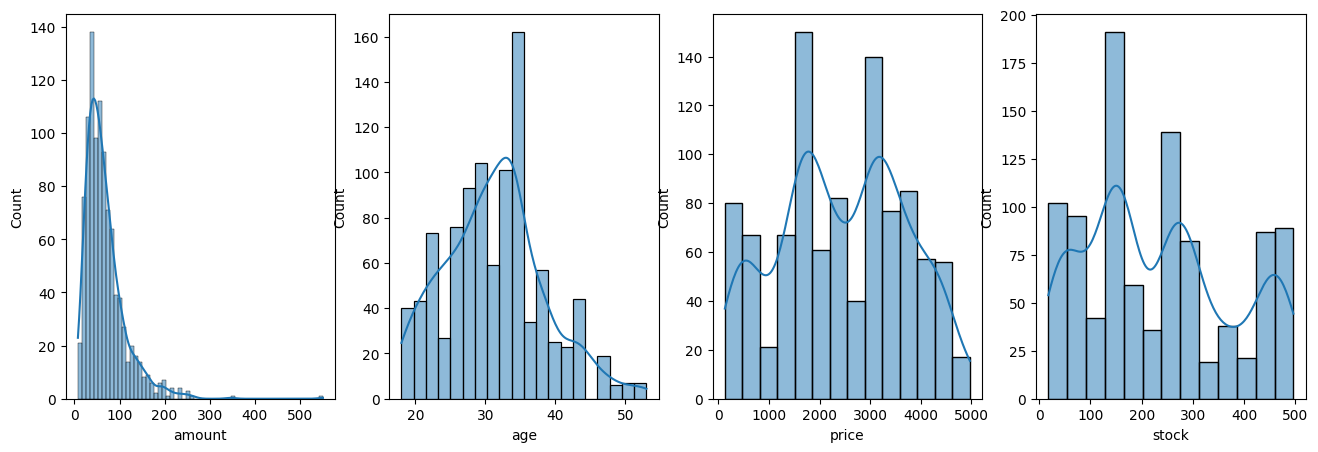

In [19]:
# cheacking the distribution of numeric column to apply suitable outlier handling technique

_,axis = plt.subplots(1, 4, figsize=(16, 5))

sns.histplot(data=df, x='amount', kde=True, ax=axis[0])
sns.histplot(data=df, x='age', kde=True, ax=axis[1])
sns.histplot(data=df, x='price', kde=True, ax=axis[2])
sns.histplot(data=df, x='stock', kde=True, ax=axis[3])

In [20]:
# applying IQR outlier handling technique on numeric columns (amount, age, price, stock)

numeric_cols = ['amount', 'age', 'price', 'stock']

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    print(f"{col}: {outlier_mask.sum()} outliers found")

    df = df[~outlier_mask].copy()

print(f"\nRows before: {1000} | Rows after: {len(df)}")



amount: 53 outliers found
age: 19 outliers found
price: 0 outliers found
stock: 0 outliers found

Rows before: 1000 | Rows after: 928


## 4. Data Transformation 